In [1]:
import os
import sys
from pathlib import Path

_cwd = Path.cwd()
_repo_root = _cwd if (_cwd / "data").exists() else _cwd.parent
os.chdir(_repo_root)
sys.path.insert(0, str(_repo_root / "src"))
print(f"repo root: {_repo_root}")

repo root: c:\Users\surya\OneDrive\Desktop\Deep-Learning-for-CT-Image-Quality-Assessment


In [2]:
import json
import logging

import matplotlib.pyplot as plt
import numpy as np
import torch

from ct_iqa.config import ExperimentConfig
from ct_iqa.data.ldct_iqac import LDCTIQACDataset, SCORE_MIN, SCORE_MAX
from ct_iqa.evaluation.metrics import compute_metrics, compute_metrics_with_logistic_mapping
from ct_iqa.models.ohashi_resnet50 import OhashiResNet50, INPUT_SIZE
from ct_iqa.training.trainer import (
    build_dataloaders,
    build_test_dataloader,
    build_loss,
    build_optimizer,
    evaluate_loader,
    train,
    train_one_step,
)
from ct_iqa.utils.seed import set_seed

logging.basicConfig(level=logging.INFO)
%matplotlib inline

print(f"torch: {torch.__version__}  cuda available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"device: {torch.cuda.get_device_name(0)}")

torch: 2.5.1+cu121  cuda available: True
device: NVIDIA GeForce RTX 4060 Laptop GPU


In [3]:
# RadImageNet weights: no official release is available to this project (the
# real dataset/weights are obtainable only by request at radimagenet.com).
# Rather than use unverified third-party "RadImageNet" checkpoints found on
# the Hugging Face Hub and risk mislabeling the result, this run uses random
# backbone initialization and is reported honestly as such -- NOT a full
# replication of the paper's RadImageNet-pretrained result.
config = ExperimentConfig(
    dropout_p=0.5,  # NOT specified by the paper -- explicit, documented choice.
    radimagenet_weights_path=None,  # No verified RadImageNet weights available; see above.
    checkpoint_dir="checkpoints/ohashi_resnet50_random_init_exp01",
    device="cuda" if torch.cuda.is_available() else "cpu",
)
set_seed(config.seed)
config

ExperimentConfig(seed=42, batch_size=64, epochs=30, learning_rate=0.001, optimizer='adam', loss='mse', image_size=224, dropout_p=0.5, train_image_dir='data/training/image', train_json_path='data/training/train.json', test_image_dir='data/testing/images', test_json_path='data/testing/test.json', val_fraction=0.1, radimagenet_weights_path=None, checkpoint_dir='checkpoints/ohashi_resnet50_random_init_exp01', device='cuda')

In [4]:
print("train image dir:", config.train_image_dir)
print("train json     :", config.train_json_path)
print("test image dir :", config.test_image_dir)
print("test json      :", config.test_json_path)

for p in [config.train_image_dir, config.train_json_path, config.test_image_dir, config.test_json_path]:
    assert Path(p).exists(), f"missing: {p}"
print("all dataset paths exist.")

train image dir: data/training/image
train json     : data/training/train.json
test image dir : data/testing/images
test json      : data/testing/test.json
all dataset paths exist.


In [5]:
train_dataset = LDCTIQACDataset(config.train_image_dir, config.train_json_path, image_size=config.image_size)
test_dataset = LDCTIQACDataset(config.test_image_dir, config.test_json_path, image_size=config.image_size)

print(f"training samples: {len(train_dataset)}")
print(f"testing samples : {len(test_dataset)}")
print(f"score range (dataset constants): [{SCORE_MIN}, {SCORE_MAX}]")
print(f"observed train score range: [{min(train_dataset.raw_scores)}, {max(train_dataset.raw_scores)}]")
print(f"observed test score range : [{min(test_dataset.raw_scores)}, {max(test_dataset.raw_scores)}]")

training samples: 1000
testing samples : 300
score range (dataset constants): [0.0, 4.0]
observed train score range: [0.0, 4.0]
observed test score range : [0.0, 4.0]


In [6]:
train_loader, val_loader = build_dataloaders(config)
test_loader = build_test_dataloader(config)

print(f"train batches: {len(train_loader)}  ({len(train_loader.dataset)} samples)")
print(f"val batches  : {len(val_loader)}  ({len(val_loader.dataset)} samples)")
print(f"test batches : {len(test_loader)}  ({len(test_loader.dataset)} samples)")

train batches: 15  (900 samples)
val batches  : 2  (100 samples)
test batches : 5  (300 samples)


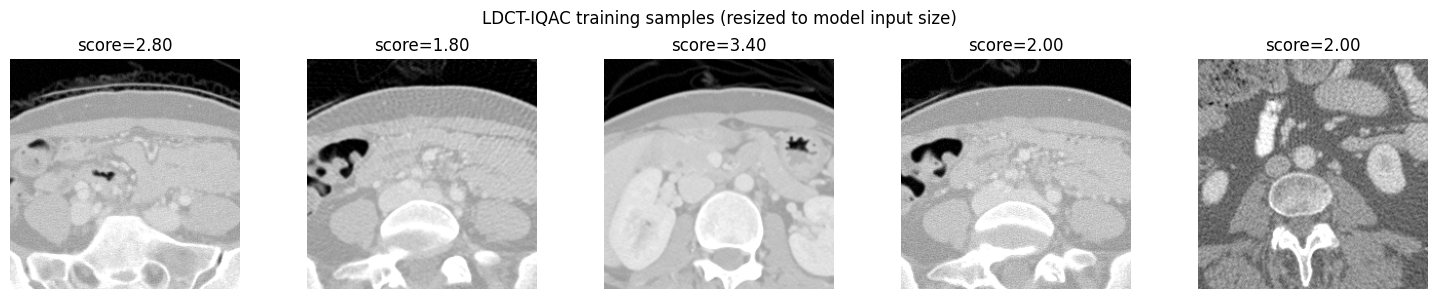

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    image, score = train_dataset[i]
    ax.imshow(image.squeeze(0).numpy(), cmap="gray")
    ax.set_title(f"score={float(score):.2f}")
    ax.axis("off")
plt.suptitle("LDCT-IQAC training samples (resized to model input size)")
plt.tight_layout()
plt.show()

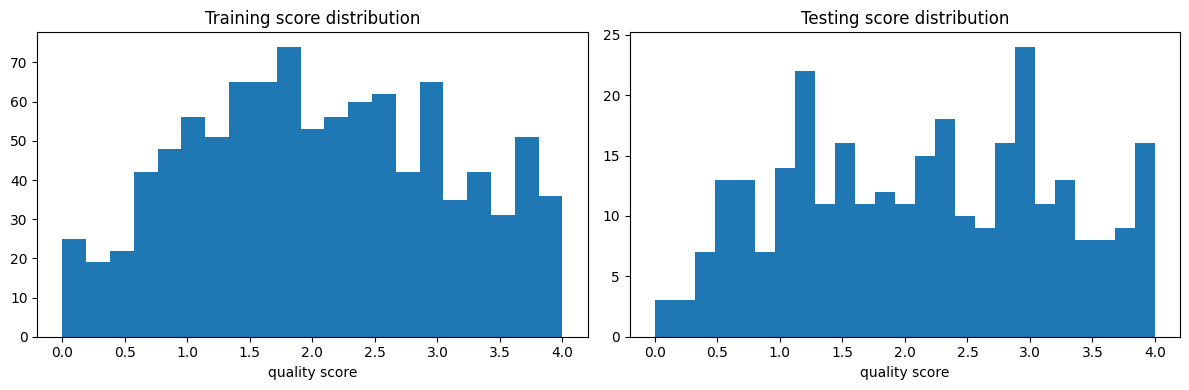

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_dataset.raw_scores, bins=21)
axes[0].set_title("Training score distribution")
axes[0].set_xlabel("quality score")

axes[1].hist(test_dataset.raw_scores, bins=25)
axes[1].set_title("Testing score distribution")
axes[1].set_xlabel("quality score")
plt.tight_layout()
plt.show()

In [9]:
model = OhashiResNet50(dropout_p=config.dropout_p, in_channels=1)
model.to(config.device)
print(model)

OhashiResNet50(
  (backbone): ResNet50Backbone(
    (stem): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    )
    (stage1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
   

In [10]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"total parameters    : {total_params:,}")
print(f"trainable parameters: {trainable_params:,}")
print(f"backbone output dim : {model.fc.in_features}")
print(f"head                : Dropout(p={config.dropout_p}) -> Linear({model.fc.in_features}, 1) -> Sigmoid")

total parameters    : 23,510,081
trainable parameters: 23,510,081
backbone output dim : 2048
head                : Dropout(p=0.5) -> Linear(2048, 1) -> Sigmoid


In [11]:
dummy_input = torch.randn(2, 1, INPUT_SIZE, INPUT_SIZE).to(config.device)
model.eval()
with torch.no_grad():
    dummy_output = model(dummy_input)
print(f"input shape : {tuple(dummy_input.shape)}")
print(f"output shape: {tuple(dummy_output.shape)}")
assert dummy_output.shape == (2,)
print("shapes OK.")

input shape : (2, 1, 224, 224)
output shape: (2,)
shapes OK.


In [12]:
assert trainable_params == total_params, "expected all parameters trainable (no layers frozen in this baseline)"
print(f"all {trainable_params:,} parameters are trainable (no frozen layers in this baseline configuration).")

all 23,510,081 parameters are trainable (no frozen layers in this baseline configuration).


In [13]:
sample_images, sample_scores = next(iter(train_loader))
model.eval()
with torch.no_grad():
    sample_predictions = model(sample_images.to(config.device))

print(f"batch input shape : {tuple(sample_images.shape)}")
print(f"batch output shape: {tuple(sample_predictions.shape)}")
print(f"output range       : [{sample_predictions.min().item():.4f}, {sample_predictions.max().item():.4f}]")
print(f"any NaN in output  : {torch.isnan(sample_predictions).any().item()}")
assert not torch.isnan(sample_predictions).any()

batch input shape : (64, 1, 224, 224)
batch output shape: (64,)
output range       : [0.5020, 0.5027]
any NaN in output  : False


In [14]:
optimizer = build_optimizer(model, config)
criterion = build_loss(config)
print(optimizer)
print(criterion)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
MSELoss()


In [15]:
RUN_FULL_TRAINING = True  # Explicitly enabled -- user-instructed full training run.

if RUN_FULL_TRAINING:
    history = train(model, train_loader, val_loader, config)
else:
    history = None
    print("RUN_FULL_TRAINING is False -- skipping full training loop.")

INFO:ct_iqa.training.trainer:epoch 1/30  train_loss=0.177505  val_loss=0.342995
INFO:ct_iqa.training.trainer:epoch 2/30  train_loss=0.115409  val_loss=0.370997
INFO:ct_iqa.training.trainer:epoch 3/30  train_loss=0.043794  val_loss=0.113539
INFO:ct_iqa.training.trainer:epoch 4/30  train_loss=0.025081  val_loss=0.030864
INFO:ct_iqa.training.trainer:epoch 5/30  train_loss=0.024690  val_loss=0.082286
INFO:ct_iqa.training.trainer:epoch 6/30  train_loss=0.017777  val_loss=0.343025
INFO:ct_iqa.training.trainer:epoch 7/30  train_loss=0.018097  val_loss=0.044817
INFO:ct_iqa.training.trainer:epoch 8/30  train_loss=0.016250  val_loss=0.060931
INFO:ct_iqa.training.trainer:epoch 9/30  train_loss=0.016949  val_loss=0.042895
INFO:ct_iqa.training.trainer:epoch 10/30  train_loss=0.013057  val_loss=0.041129
INFO:ct_iqa.training.trainer:epoch 11/30  train_loss=0.013269  val_loss=0.219340
INFO:ct_iqa.training.trainer:epoch 12/30  train_loss=0.016512  val_loss=0.187610
INFO:ct_iqa.training.trainer:epoch 13

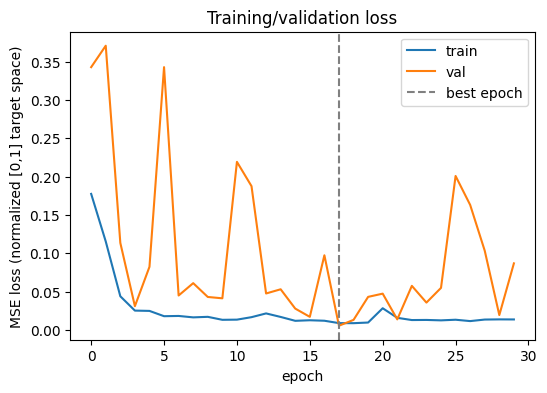

In [16]:
if history is not None:
    plt.figure(figsize=(6, 4))
    plt.plot(history.train_loss, label="train")
    plt.plot(history.val_loss, label="val")
    plt.axvline(history.best_epoch, color="gray", linestyle="--", label="best epoch")
    plt.xlabel("epoch")
    plt.ylabel("MSE loss (normalized [0,1] target space)")
    plt.legend()
    plt.title("Training/validation loss")
    plt.show()
else:
    print("No training history -- full training was not run in this notebook execution.")

In [17]:
best_checkpoint_path = Path(config.checkpoint_dir) / "best.pt"
if best_checkpoint_path.exists():
    model.load_state_dict(torch.load(best_checkpoint_path, map_location=config.device))
    print(f"loaded best checkpoint from {best_checkpoint_path}")
else:
    print(f"no checkpoint found at {best_checkpoint_path} (expected -- full training was not run).")

loaded best checkpoint from checkpoints\ohashi_resnet50_random_init_exp01\best.pt


C:\Users\surya\AppData\Local\Temp\ipykernel_15816\1662601639.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_checkpoint_path, map_l

In [18]:
test_loss, test_predictions, test_targets = evaluate_loader(model, test_loader, criterion, device=config.device)
print(f"test loss (normalized-space MSE): {test_loss:.6f}")

raw_metrics = compute_metrics(test_targets.numpy(), test_predictions.numpy())
print("Raw-space metrics (no logistic mapping):")
for k, v in raw_metrics.items():
    print(f"  {k.upper():6s}: {v:.4f}")

test loss (normalized-space MSE): 0.022340
Raw-space metrics (no logistic mapping):
  MSE   : 0.3574
  PLCC  : 0.8481
  SROCC : 0.8445
  KROCC : 0.6512


In [19]:
try:
    logistic_metrics = compute_metrics_with_logistic_mapping(test_targets.numpy(), test_predictions.numpy())
    print("5PL-mapped metrics:")
    for k, v in logistic_metrics.items():
        print(f"  {k.upper():6s}: {v:.4f}")
except Exception as e:
    print(f"5PL fit did not converge (expected with an under-trained/random model): {e}")
    logistic_metrics = None

5PL-mapped metrics:
  MSE   : 0.3278
  PLCC  : 0.8501
  SROCC : 0.8444
  KROCC : 0.6512


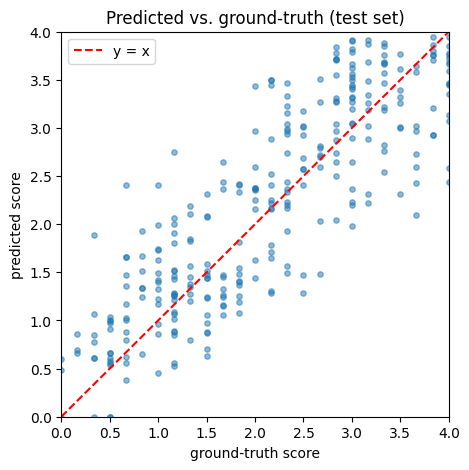

In [20]:
plt.figure(figsize=(5, 5))
plt.scatter(test_targets.numpy(), test_predictions.numpy(), alpha=0.5, s=15)
plt.plot([SCORE_MIN, SCORE_MAX], [SCORE_MIN, SCORE_MAX], "r--", label="y = x")
plt.xlabel("ground-truth score")
plt.ylabel("predicted score")
plt.xlim(SCORE_MIN, SCORE_MAX)
plt.ylim(SCORE_MIN, SCORE_MAX)
plt.legend()
plt.title("Predicted vs. ground-truth (test set)")
plt.show()

In [21]:
output_dir = Path(config.checkpoint_dir)
output_dir.mkdir(parents=True, exist_ok=True)

predictions_path = output_dir / "test_predictions.json"
predictions_record = {
    fn: {"ground_truth": gt, "predicted": pred}
    for fn, gt, pred in zip(
        [s.filename for s in test_dataset.samples],
        test_targets.tolist(),
        test_predictions.tolist(),
    )
}
predictions_path.write_text(json.dumps(predictions_record, indent=2))
print(f"saved predictions to {predictions_path}")

saved predictions to checkpoints\ohashi_resnet50_random_init_exp01\test_predictions.json


In [22]:
metrics_path = output_dir / "test_metrics.json"
metrics_record = {"raw": raw_metrics, "logistic_mapped": logistic_metrics}
metrics_path.write_text(json.dumps(metrics_record, indent=2))
print(f"saved metrics to {metrics_path}")

saved metrics to checkpoints\ohashi_resnet50_random_init_exp01\test_metrics.json


In [23]:
config_path = output_dir / "config.json"
config.save(config_path)
print(f"saved experiment configuration to {config_path}")

saved experiment configuration to checkpoints\ohashi_resnet50_random_init_exp01\config.json
